<a href="https://colab.research.google.com/github/oluwoleadetifa/movie_genre_classification/blob/dev/notebooks/02_text_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!rm -rf /content/movie_genre_classification
!git clone https://github.com/oluwoleadetifa/movie_genre_classification.git
%cd /content/movie_genre_classification

Cloning into 'movie_genre_classification'...
remote: Enumerating objects: 269, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 269 (delta 39), reused 19 (delta 8), pack-reused 185 (from 1)
Receiving objects: 100% (269/269), 1.40 MiB | 5.01 MiB/s, done.
Resolving deltas: 100% (129/129), done.
/content/movie_genre_classification


In [9]:
from google.colab import files
uploaded = files.upload()

Saving movies_with_posters.csv to movies_with_posters.csv


In [10]:
import os
print("cwd:", os.getcwd())
print(os.listdir(os.getcwd()))

cwd: /content/movie_genre_classification
['helper.txt', 'requirements-lock.txt', '.git', 'experiments', '.env.example', 'setup.sh', 'docs', 'data', 'README.md', 'movies_with_posters.csv', 'requirements.txt', 'notebooks', 'environment.yml', 'outputs', '.gitignore', 'src']


In [11]:
import os
import shutil

cwd = os.getcwd()
files_here = os.listdir(cwd)
matches = [f for f in files_here if "movies_with_posters" in f]

print("Matches:", matches)

if not matches:
    raise FileNotFoundError("movies_with_posters file was not uploaded")

shutil.move(
    os.path.join(cwd, matches[0]),
    "/content/movie_genre_classification/data/processed/movies_with_posters.csv"
)

print("Moved:", matches[0])
print("processed:", os.listdir("/content/movie_genre_classification/data/processed"))

Matches: ['movies_with_posters.csv']
Moved: movies_with_posters.csv
processed: ['.gitkeep', 'movies_with_posters.csv']


In [13]:
config_text = """
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SPLITS_DIR = DATA_DIR / "splits"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUT_DIR / "models"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"

for folder in [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    SPLITS_DIR,
    OUTPUT_DIR,
    MODELS_DIR,
    METRICS_DIR,
    FIGURES_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

DATA_CSV = PROCESSED_DATA_DIR / "movies_with_posters.csv"

TRAIN_SPLIT_CSV = SPLITS_DIR / "train.csv"
VAL_SPLIT_CSV = SPLITS_DIR / "val.csv"
TEST_SPLIT_CSV = SPLITS_DIR / "test.csv"

TEXT_COLUMN = "description"
ID_COLUMN = "movie_id"
LABEL_COLUMN = "label"
GENRE_COLUMN = "genre"
IMAGE_PATH_COLUMN = "image_path"

CLASS_NAMES = ["action", "comedy", "horror", "romance"]
"""

with open("/content/movie_genre_classification/src/config.py", "w") as f:
    f.write(config_text)

import importlib
import src.config
import src.data.load_data

importlib.reload(src.config)
importlib.reload(src.data.load_data)

print("config reloaded")

config reloaded


In [14]:
from src.data.load_data import load_dataset, basic_dataset_check

df = load_dataset()
basic_dataset_check(df)
df.head()

Dataset shape: (687, 6)

Columns:
['movie_id', 'description', 'genre', 'image_path', 'image_exists', 'label']

Missing descriptions:
0

Genre distribution:
label
2    250
0    239
1    106
3     92
Name: count, dtype: int64


,movie_id,description,genre,image_path,image_exists,label
0,tt1798632,A young girl tries to understand how she myste...,horror,/Users/oluwoleadetifa/Library/CloudStorage/Goo...,True,2
1,tt9214832,"In 1800s England, a well meaning but selfish y...",comedy,/Users/oluwoleadetifa/Library/CloudStorage/Goo...,True,1
2,tt21249656,Olga and Maks are 15 years apart. She is a suc...,romance,/Users/oluwoleadetifa/Library/CloudStorage/Goo...,True,3
3,tt7149730,A reformed hunter living in isolation on a wil...,action,/Users/oluwoleadetifa/Library/CloudStorage/Goo...,True,0
4,tt3876910,A reformed sociopath journeys to a remote isla...,action,/Users/oluwoleadetifa/Library/CloudStorage/Goo...,True,0


In [15]:
import pandas as pd

train_df = pd.read_csv("/content/movie_genre_classification/data/splits/train.csv")
val_df = pd.read_csv("/content/movie_genre_classification/data/splits/val.csv")
test_df = pd.read_csv("/content/movie_genre_classification/data/splits/test.csv")

print(train_df.shape, val_df.shape, test_df.shape)

(480, 6) (103, 6) (104, 6)


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

TEXT_COLUMN = "description"
LABEL_COLUMN = "label"

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_df[TEXT_COLUMN])
X_val = vectorizer.transform(val_df[TEXT_COLUMN])
X_test = vectorizer.transform(test_df[TEXT_COLUMN])

y_train = train_df[LABEL_COLUMN]
y_val = val_df[LABEL_COLUMN]
y_test = test_df[LABEL_COLUMN]

print(X_train.shape)

(480, 5000)


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6538461538461539
              precision    recall  f1-score   support

           0       0.61      0.92      0.73        36
           1       0.00      0.00      0.00        16
           2       0.69      0.89      0.78        38
           3       1.00      0.07      0.13        14

    accuracy                           0.65       104
   macro avg       0.58      0.47      0.41       104
weighted avg       0.60      0.65      0.56       104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


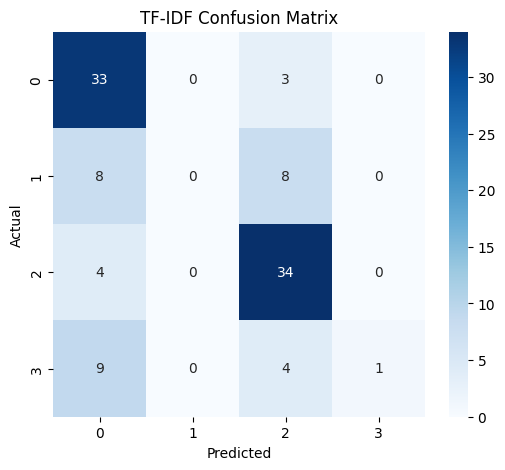

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TF-IDF Confusion Matrix")
plt.show()

In [20]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

coefs = model.coef_

for i, class_label in enumerate(model.classes_):
    top10 = np.argsort(coefs[i])[-10:]
    print(f"\nTop words for class {class_label}:")
    print([feature_names[j] for j in top10])


Top words for class 0:
['man', 'gang', 'agent', 'battle', 'criminal', 'dangerous', 'team', 'war', 'world', 'mission']

Top words for class 1:
['borat', 'ron', 'sid', 'luck', 'luca', 'mimi', 'kate', 'marcus', 'star', 'max']

Top words for class 2:
['horror', 'demonic', 'demon', 'nightmare', 'supernatural', 'mother', 'dark', 'town', 'night', 'house']

Top words for class 3:
['marriage', 'movie', 'maren', 'lucy', 'maggie', 'relationship', 'henry', 'hardin', 'tessa', 'love']
